<a href="https://colab.research.google.com/github/Dheepthi-Reddy/Transformer_From_Scratch/blob/main/Transformer_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention Is All You Need — Implementation From Scratch
### A scaled-down, Transformer built in PyTorch

Building the Transformer architecture inspired from the original paper *(Vaswani et al., 2017)* and trains it on a small English→German translation dataset (Multi30k).

**Config used** (trained on a free Colab GPU):
| Parameter | Paper (base) | This notebook |
|---|---|---|
| Layers (N) | 6 | 3 |
| d_model | 512 | 256 |
| Feed-forward dim | 2048 | 512 |
| Attention heads | 8 | 4 |
| Batch size | — | 64 |
| Epochs | 300K steps | 10 |

---
## Step 0 — Enable GPU in Colab
Change runtime type to GPU (T4).


In [64]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


---
## Step 1 — Installing dependencies

We need:
- `torch`
- Using HuggingFace `datasets` + `tokenizers`
- `sacrebleu` for BLEU score evaluation


In [65]:
!pip install -q datasets tokenizers sacrebleu

---
## Step 2 — Load the dataset (Multi30k, English→German)

Used a small Multi30k — for a scaled-down run. We are loading it directly from HuggingFace `datasets`.


In [66]:
from datasets import load_dataset

# bentrevett/multi30k is a clean HF mirror of the classic Multi30k dataset
raw_dataset = load_dataset("bentrevett/multi30k")
print(raw_dataset)
print()
print("Sample:", raw_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

Sample: {'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}


We can see the dict with `train`, `validation`, and `test` splits, each containing `en` and `de` fields.

---
## Step 3 — Build tokenizers and vocabulary

I am using a simple whitespace + punctuation tokenization. Building one vocabulary for English, one for German.


In [67]:
import re
from collections import Counter

def tokenize(text):
    text = text.lower().strip()
    text = re.sub(r"([.,!?\"'])", r" \1 ", text)
    return text.split()

SPECIALS = ["<unk>", "<pad>", "<bos>", "<eos>"]
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

def build_vocab(sentences, min_freq=2):
    counter = Counter()
    for s in sentences:
        counter.update(tokenize(s))
    vocab = {tok: i for i, tok in enumerate(SPECIALS)}
    for tok, freq in counter.items():
        if freq >= min_freq:
            vocab[tok] = len(vocab)
    return vocab

train_en = [ex["en"] for ex in raw_dataset["train"]]
train_de = [ex["de"] for ex in raw_dataset["train"]]

en_vocab = build_vocab(train_en)
de_vocab = build_vocab(train_de)

en_itos = {i: t for t, i in en_vocab.items()}
de_itos = {i: t for t, i in de_vocab.items()}

print(f"English vocab size: {len(en_vocab)}")
print(f"German vocab size: {len(de_vocab)}")

English vocab size: 5922
German vocab size: 7821


---
## Step 4 — Convert text to numeric tensors

Each sentence becomes a list of token IDs, wrapped with `<bos>` and `<eos>`.


In [68]:
def encode(text, vocab):
    ids = [vocab.get(tok, UNK_IDX) for tok in tokenize(text)]
    return [BOS_IDX] + ids + [EOS_IDX]

# quick sanity check
sample_ids = encode(train_en[0], en_vocab)
print(train_en[0])
print(sample_ids)

Two young, White males are outside near many bushes.
[2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 3]


---
## Step 5 — Building a PyTorch Dataset + DataLoader with padding

Sentences have different lengths, so we pad each batch to the longest sentence in that batch.


In [69]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TranslationDataset(Dataset):
    def __init__(self, split, src_vocab, tgt_vocab, max_len=80):
        self.data = []
        for ex in split:
            src_ids = encode(ex["en"], src_vocab)[:max_len]
            tgt_ids = encode(ex["de"], tgt_vocab)[:max_len]
            self.data.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.data)
    # fetching one example by index
    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        return torch.tensor(src), torch.tensor(tgt)

def collate_fn(batch):
    # groups 64 sentence into a batch
    src_batch, tgt_batch = zip(*batch)
    # pads every sentence matching longest sentence
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    return src_batch, tgt_batch

train_ds = TranslationDataset(raw_dataset["train"], en_vocab, de_vocab)
valid_ds = TranslationDataset(raw_dataset["validation"], en_vocab, de_vocab)
test_ds  = TranslationDataset(raw_dataset["test"], en_vocab, de_vocab)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, generator=torch.Generator().manual_seed(42))
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)} | Test batches: {len(test_loader)}")

src_sample, tgt_sample = next(iter(train_loader))
print("Source batch shape:", src_sample.shape)
print("Target batch shape:", tgt_sample.shape)

Train batches: 454 | Valid batches: 16 | Test batches: 16
Source batch shape: torch.Size([64, 26])
Target batch shape: torch.Size([64, 24])


---
## Step 6 — Building the Transformer architecture (the core of the paper)

We build it piece by piece, following the paper's structure:

1. Positional Encoding
2. Scaled Dot-Product Attention
3. Multi-Head Attention
4. Position-wise Feed-Forward Network
5. Encoder Layer -> Encoder Stack
6. Decoder Layer -> Decoder Stack
7. Full Transformer (embeddings + encoder + decoder + output projection)

### 6.1 — Positional Encoding

Since there's no recurrence, the model needs another way to know word order. We use fixed sine/cosine waves of different frequencies.


In [70]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # shape: (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

### 6.2 — Scaled Dot-Product Attention

The core equation:

Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V


In [71]:
def scaled_dot_product_attention(q, k, v, mask=None):
    # q, k, v shape: (batch, heads, seq_len, d_k)
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (batch, heads, seq_len, seq_len)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-1e9"))

    attn_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, v)
    return output, attn_weights

### 6.3 — Multi-Head Attention

Instead of one attention computation, we split into `h` heads, each attending to different relationships, then concatenate the results.


In [72]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_len, d_model = x.size()
        return x.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, num_heads, seq_len, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_len, num_heads * d_k)

    def forward(self, q, k, v, mask=None):
        q = self.split_heads(self.w_q(q))
        k = self.split_heads(self.w_k(k))
        v = self.split_heads(self.w_v(v))

        attn_output, _ = scaled_dot_product_attention(q, k, v, mask)
        output = self.combine_heads(attn_output)
        return self.w_o(output)

### 6.4 — Position-wise Feed-Forward Network

A simple 2-layer MLP applied independently to every position.


In [73]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.relu(self.linear1(x)))

### 6.5 — Encoder Layer

Each encoder layer = Self-Attention -> Add & Norm -> Feed-Forward -> Add & Norm


In [74]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

### 6.6 — Decoder Layer

Each decoder layer = Masked Self-Attention -> Add & Norm -> Cross-Attention (with encoder output) -> Add & Norm -> Feed-Forward -> Add & Norm


In [75]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))

        cross_out = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(cross_out))

        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

### 6.7 — Full Transformer

Stacks N encoder layers and N decoder layers, adds embeddings + positional encoding, and a final linear+softmax projection to vocabulary size.


In [76]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=4,
                 num_layers=3, d_ff=512, max_len=200, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
        self.positional_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

        self.output_projection = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def make_src_mask(self, src):
        # (batch, 1, 1, src_len) — masks padding tokens
        return (src != PAD_IDX).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        batch_size, tgt_len = tgt.size()
        pad_mask = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, tgt_len)
        causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).bool()
        return pad_mask & causal_mask  # combines padding mask + look-ahead mask

    def encode(self, src, src_mask):
        x = self.dropout(self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model)))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_output, src_mask, tgt_mask):
        x = self.dropout(self.positional_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model)))
        for layer in self.decoder_layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_output = self.encode(src, src_mask)
        dec_output = self.decode(tgt, enc_output, src_mask, tgt_mask)

        return self.output_projection(dec_output)

---
## Step 7 — Instantiate the model

Using the scaled-down config.


In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(de_vocab),
    d_model=256,
    num_heads=4,
    num_layers=3,
    d_ff=512,
    dropout=0.1
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params:,}")

Total trainable parameters: 9,481,869


---
## Step 8 — Loss function and optimizer

- **Label smoothing** (0.1) — prevents the model from being overconfident
- **Adam optimizer** with a fixed learning rate of 1e-4



In [78]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

class WarmupScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=400):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(self.step_num ** -0.5, self.step_num * self.warmup_steps ** -1.5)
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr
        self.optimizer.step()

scheduler = WarmupScheduler(optimizer, d_model=256, warmup_steps=400)

---
## Step 9 — Training loop

For each batch:
1. Feed the target shifted right (teacher forcing) as decoder input
2. Predict the next token at each position
3. Compare against the actual next token


In [79]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0

    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input = tgt[:, :-1]   # everything except last token (decoder input)
        tgt_output = tgt[:, 1:]   # everything except first token (what we predict)

        optimizer.zero_grad()
        logits = model(src, tgt_input)  # (batch, seq_len, vocab_size)

        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(dataloader)

---
## Step 10 — Run training

This scaled-down model on Multi30k trains in roughly 3-5 minutes on a free Colab T4 GPU for 10 epochs. Each epoch takes about 15 seconds.

In [80]:
import time

NUM_EPOCHS = 10
best_valid_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    valid_loss = evaluate(model, valid_loader, criterion, device)
    elapsed = time.time() - start

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_transformer.pt")

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.3f} | Valid Loss: {valid_loss:.3f} | Time: {elapsed:.1f}s")

Epoch 01 | Train Loss: 4.728 | Valid Loss: 3.921 | Time: 18.5s
Epoch 02 | Train Loss: 3.752 | Valid Loss: 3.536 | Time: 15.6s
Epoch 03 | Train Loss: 3.385 | Valid Loss: 3.253 | Time: 15.3s
Epoch 04 | Train Loss: 3.135 | Valid Loss: 3.099 | Time: 15.2s
Epoch 05 | Train Loss: 2.948 | Valid Loss: 2.993 | Time: 15.5s
Epoch 06 | Train Loss: 2.810 | Valid Loss: 2.935 | Time: 15.2s
Epoch 07 | Train Loss: 2.699 | Valid Loss: 2.884 | Time: 16.4s
Epoch 08 | Train Loss: 2.605 | Valid Loss: 2.862 | Time: 15.7s
Epoch 09 | Train Loss: 2.520 | Valid Loss: 2.847 | Time: 15.2s
Epoch 10 | Train Loss: 2.452 | Valid Loss: 2.828 | Time: 15.2s


---
## Step 11 — Translate a sentence (greedy decoding)

Now let's actually use the trained model to translate English -> German, one token at a time.


In [81]:
def translate_sentence(model, sentence, src_vocab, tgt_vocab, tgt_itos, device, max_len=50):
    model.eval()
    src_ids = torch.tensor([encode(sentence, src_vocab)]).to(device)
    src_mask = model.make_src_mask(src_ids)

    with torch.no_grad():
        enc_output = model.encode(src_ids, src_mask)

    tgt_ids = [BOS_IDX]
    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_ids]).to(device)
        tgt_mask = model.make_tgt_mask(tgt_tensor)

        with torch.no_grad():
            dec_output = model.decode(tgt_tensor, enc_output, src_mask, tgt_mask)
            logits = model.output_projection(dec_output)

        next_token = logits[0, -1].argmax().item()
        tgt_ids.append(next_token)

        if next_token == EOS_IDX:
            break

    tokens = [tgt_itos[i] for i in tgt_ids[1:-1]]  # strip <bos> and <eos>
    return " ".join(tokens)

# load best checkpoint
model.load_state_dict(torch.load("best_transformer.pt"))

test_sentences = [
    "a man is riding a horse",
    "two young women are walking down the street",
    "a dog is running in the park"
]

for sent in test_sentences:
    translation = translate_sentence(model, sent, en_vocab, de_vocab, de_itos, device)
    print(f"EN: {sent}")
    print(f"DE: {translation}")
    print()

EN: a man is riding a horse
DE: ein mann reitet auf einem pferd .

EN: two young women are walking down the street
DE: zwei junge frauen gehen die straße entlang .

EN: a dog is running in the park
DE: ein hund rennt im park .



---
## Step 12 — Evaluate with BLEU score

BLEU (Bilingual Evaluation Understudy) measures translation quality by comparing the model's output against reference translations. A score of 0 means no overlap, 100 means perfect match. We evaluate on 200 test sentences and apply a detokenization fix before scoring to ensure punctuation spacing does not artificially lower the result.


In [82]:
import sacrebleu
import re

def detokenize(text):
    text = re.sub(r"\s+([.,!?])", r"\1", text)
    return text

def get_bleu_score(model, dataloader_raw, src_vocab, tgt_vocab, tgt_itos, device, n_samples=200):
    model.eval()
    predictions = []
    references = []

    for i, ex in enumerate(dataloader_raw):
        if i >= n_samples:
            break
        pred = translate_sentence(model, ex["en"], src_vocab, tgt_vocab, tgt_itos, device)
        pred = detokenize(pred)
        predictions.append(pred)
        references.append(ex["de"])

    bleu = sacrebleu.corpus_bleu(predictions, [references])
    return bleu.score
bleu_score = get_bleu_score(model, raw_dataset["test"], en_vocab, de_vocab, de_itos, device)
print(f"BLEU score on 200 test samples: {bleu_score:.2f}")

BLEU score on 200 test samples: 4.48


---
## Step 13 — Visualize attention weights

Visualizing cross-attention alignment between English source words and German target words. Lines connecting the two sides show which source words the decoder attended to when generating each target word. Thicker and darker lines indicate stronger attention.


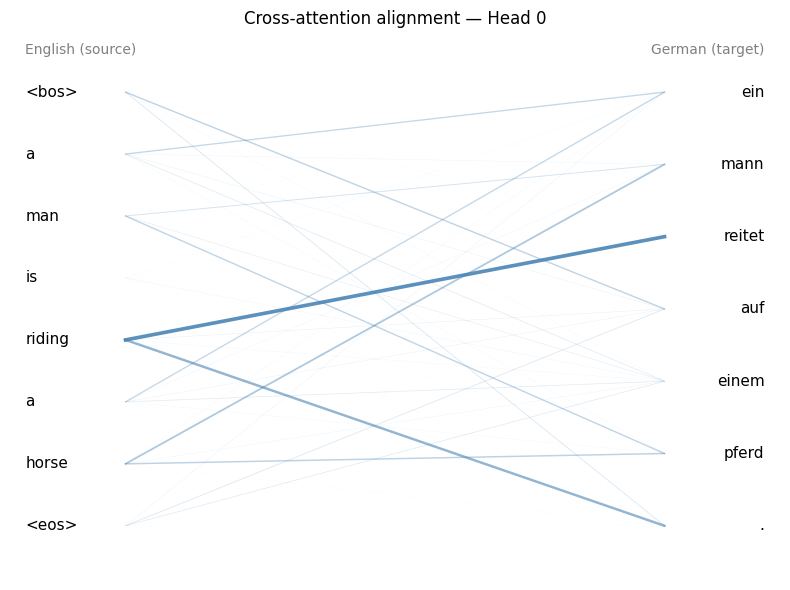

In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_attention_alignment(model, sentence, src_vocab, tgt_vocab, tgt_itos, device, head_idx=0):
    model.eval()

    src_ids = torch.tensor([encode(sentence, src_vocab)]).to(device)
    src_mask = model.make_src_mask(src_ids)

    with torch.no_grad():
        enc_output = model.encode(src_ids, src_mask)

    tgt_ids = [BOS_IDX]
    for _ in range(50):
        tgt_tensor = torch.tensor([tgt_ids]).to(device)
        tgt_mask = model.make_tgt_mask(tgt_tensor)
        with torch.no_grad():
            dec_output = model.decode(tgt_tensor, enc_output, src_mask, tgt_mask)
            logits = model.output_projection(dec_output)
        next_token = logits[0, -1].argmax().item()
        tgt_ids.append(next_token)
        if next_token == EOS_IDX:
            break

    tgt_tensor = torch.tensor([tgt_ids]).to(device)
    tgt_mask = model.make_tgt_mask(tgt_tensor)

    with torch.no_grad():
        x = model.dropout(model.positional_encoding(model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model)))
        cross_attn_weights = None
        for layer in model.decoder_layers:
            q = layer.cross_attn.split_heads(layer.cross_attn.w_q(x))
            k = layer.cross_attn.split_heads(layer.cross_attn.w_k(enc_output))
            v = layer.cross_attn.split_heads(layer.cross_attn.w_v(enc_output))
            _, cross_attn_weights = scaled_dot_product_attention(q, k, v, src_mask)
            attn_out = layer.cross_attn(x, enc_output, enc_output, src_mask)
            x = layer.norm2(x + layer.dropout(attn_out))
            ff_out = layer.feed_forward(x)
            x = layer.norm3(x + layer.dropout(ff_out))

    attn = cross_attn_weights[0, head_idx].cpu().numpy()

    src_tokens = [en_itos.get(i, "<unk>") for i in src_ids[0].tolist()]
    tgt_tokens = [tgt_itos.get(i, "<unk>") for i in tgt_ids[1:] if i != EOS_IDX]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    n_src = len(src_tokens)
    n_tgt = len(tgt_tokens)

    src_y = np.linspace(0.9, 0.1, n_src)
    tgt_y = np.linspace(0.9, 0.1, n_tgt)

    for i, (tok, y) in enumerate(zip(src_tokens, src_y)):
        ax.text(0.02, y, tok, ha="left", va="center", fontsize=11, color="black")

    for j, (tok, y) in enumerate(zip(tgt_tokens, tgt_y)):
        ax.text(0.98, y, tok, ha="right", va="center", fontsize=11, color="black")

    for j, ty in enumerate(tgt_y):
        if j >= attn.shape[0]:
            break
        for i, sy in enumerate(src_y):
            if i >= attn.shape[1]:
                break
            weight = attn[j, i]
            ax.plot([0.15, 0.85], [sy, ty],
                   color="steelblue", alpha=float(weight),
                   linewidth=float(weight) * 3)

    ax.text(0.02, 0.97, "English (source)", ha="left", fontsize=10, color="gray")
    ax.text(0.98, 0.97, "German (target)", ha="right", fontsize=10, color="gray")
    ax.set_title(f"Cross-attention alignment — Head {head_idx}", fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()

plot_attention_alignment(model, "a man is riding a horse", en_vocab, de_vocab, de_itos, device, head_idx=0)

---
## What to expect

With this scaled-down setup, expect a **BLEU score in the 4-5 range** — far below the paper's 28.4, but that is expected given:

- 1000x less training data than WMT14
- ~7x fewer parameters (9.5M vs 65M)
- 10 epochs vs the paper's 100K-300K training steps

The goal of this notebook is not to reproduce the paper's exact numbers. It is to understand every moving part well enough to build it from scratch, and then systematically explore how each design choice affects the result.
